## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [2]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'

# Set the filepaths 
# The target grid mask 
filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_geometric_masks.nc'
# The target grid geometry
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_geom_vars.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# And the location of the output files 
filepath_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM001' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = True

## Apply neural network

In [3]:
import time

In [4]:
%%time
simulation = 'DUM003'
year = '9999'
apply_nn_to_NEMO_dummy(filepath_nemo_output, 
                             filepath_mask, 
                             filepath_geomvars, 
                             filepath_eORCA1_bmach_masks, 
                             path_model, 
                             path_norm_metrics, 
                             filepath_nn_output, 
                             simulation, 
                             year_of_interest, 
                             this_collection, 
                             exp_name, 
                             join_ice_shelves)

You have saved the nn output to: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_output_melt_DUM003_9999.nc
CPU times: user 320 ms, sys: 34.4 ms, total: 354 ms
Wall time: 1.22 s


## Look at the resulting melt distribution map for NEMO

/tmp/ipykernel_3548699/3613664947.py:7: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(melt_all), cmap = 'Blues_r')
/tmp/ipykernel_3548699/3613664947.py:8: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
/tmp/ipykernel_3548699/3613664947.py:9: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


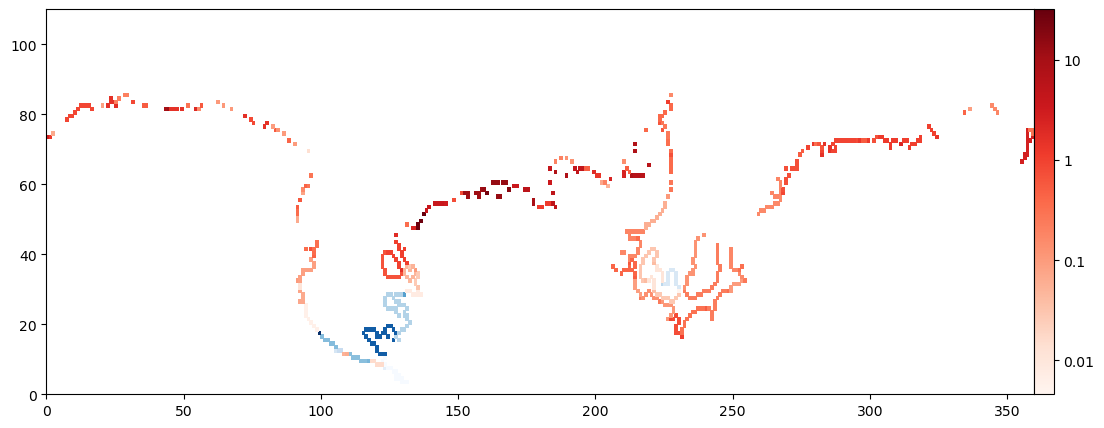

In [5]:
melt = xr.open_dataset(filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan
melt.close()

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(melt_all), cmap = 'Blues_r')
im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-2,-1,0,1))
cbar.set_ticklabels(((10**-2), (10**-1), (10**0), (10**1)))
#im.set_clim(-0.1,0)